<a href="https://colab.research.google.com/github/WickedSero/_CDV_MachineLearning/blob/main/5_-_regularyzacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Wczytaj niezbędne biblioteki

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Wstępna obróbka danych

### Wczytaj dane, zapoznaj się z nimi i je oczyść


In [ ]:
# Wczytaj dataset_test, separator to spacja, dataset nie ma nagłówków
dataset_test = pd.read_csv('/content/dataset.test.txt', sep=' ', header=None)

# Usuń kolumny, w których wszystkie wartości to NaN
dataset_test = dataset_test.dropna(axis=1, how='all')

# Wyświetl kilka pierwszych wierszy dla weryfikacji
print(dataset_test.head())

   0   1       2       3      4       5       6        7        8      9   \
0   1   1  0.0023  0.0003  100.0  518.67  643.02  1585.29  1398.21  14.62   
1   1   2 -0.0027 -0.0003  100.0  518.67  641.71  1588.45  1395.42  14.62   
2   1   3  0.0003  0.0001  100.0  518.67  642.46  1586.94  1401.34  14.62   
3   1   4  0.0042  0.0000  100.0  518.67  642.44  1584.12  1406.42  14.62   
4   1   5  0.0014  0.0000  100.0  518.67  642.51  1587.19  1401.92  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.72  2388.03  8125.55  8.4052  0.03  392  2388  100.0  38.86   
1  ...  522.16  2388.06  8139.62  8.3803  0.03  393  2388  100.0  39.02   
2  ...  521.97  2388.03  8130.10  8.4441  0.03  393  2388  100.0  39.08   
3  ...  521.38  2388.05  8132.90  8.3917  0.03  391  2388  100.0  39.00   
4  ...  522.15  2388.03  8129.54  8.4031  0.03  390  2388  100.0  38.99   

        25  
0  23.3735  
1  23.3916  
2  23.4166  
3  23.3737  
4  23.4130  

[5 rows

In [ ]:
# Wczytaj nazwy kolumn z pliku Zmienne.txt
with open('/content/Zmienne.txt', 'r') as f:
    column_names = f.read().splitlines()

# Ustaw nazwy kolumn
dataset_test.columns = column_names

# Wyświetl kilka pierwszych wierszy dla weryfikacji
print(dataset_test.head())

   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1        0.0023        0.0003         100.0   
1            1               2       -0.0027       -0.0003         100.0   
2            1               3        0.0003        0.0001         100.0   
3            1               4        0.0042        0.0000         100.0   
4            1               5        0.0014        0.0000         100.0   

   sensor_measurement_1  sensor_measurement_2  sensor_measurement_3  \
0                518.67                643.02               1585.29   
1                518.67                641.71               1588.45   
2                518.67                642.46               1586.94   
3                518.67                642.44               1584.12   
4                518.67                642.51               1587.19   

   sensor_measurement_4  sensor_measurement_5  ...  sensor_measurement_12  \
0               1398.21                

In [ ]:
dataset_test.sample(5)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
10025,77,106,0.0006,-0.0002,100.0,518.67,642.05,1583.42,1409.88,14.62,...,521.82,2388.07,8131.64,8.4320,0.03,393,2388,100.0,38.91,23.3832
10380,80,126,0.0005,0.0003,100.0,518.67,643.13,1590.26,1409.96,14.62,...,521.53,2388.07,8143.71,8.4447,0.03,393,2388,100.0,38.86,23.3350
10949,84,114,0.0022,-0.0000,100.0,518.67,642.81,1594.92,1411.36,14.62,...,521.63,2388.09,8134.37,8.4364,0.03,394,2388,100.0,38.80,23.4370
3185,27,124,-0.0005,0.0000,100.0,518.67,642.51,1589.50,1406.23,14.62,...,521.21,2388.10,8134.93,8.4233,0.03,391,2388,100.0,38.96,23.2749
7548,59,7,0.0029,0.0004,100.0,518.67,641.91,1584.95,1403.11,14.62,...,522.50,2388.00,8133.55,8.4254,0.03,392,2388,100.0,39.02,23.4735


In [ ]:
# Wczytaj dataset_train, separator to spacja, dataset nie ma nagłówków
dataset_train = pd.read_csv('/content/dataset.train.txt', sep=' ', header=None)

# Usuń kolumny, w których wszystkie wartości to NaN
dataset_train = dataset_train.dropna(axis=1, how='all')

# Ustaw nazwy kolumn takie same jak w dataset_test
dataset_train.columns = column_names

# Wyświetl kilka pierwszych wierszy dla weryfikacji
dataset_train.sample(5)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
8589,44,145,-0.0012,0.0001,100.0,518.67,642.39,1591.41,1413.63,14.62,...,521.44,2388.07,8150.02,8.4888,0.03,394,2388,100.0,38.74,23.2573
12318,63,12,-0.0012,-0.0003,100.0,518.67,642.60,1586.14,1406.98,14.62,...,521.70,2388.06,8133.77,8.4486,0.03,393,2388,100.0,38.89,23.3231
2475,12,100,-0.0032,0.0005,100.0,518.67,642.93,1592.94,1409.98,14.62,...,521.07,2388.13,8122.41,8.4480,0.03,392,2388,100.0,38.76,23.3091
1871,9,159,0.0005,0.0003,100.0,518.67,642.67,1585.67,1401.96,14.62,...,521.28,2388.01,8185.06,8.4398,0.03,394,2388,100.0,38.72,23.4176
17742,87,125,0.0019,0.0004,100.0,518.67,642.76,1598.65,1411.23,14.62,...,520.65,2388.14,8135.94,8.4623,0.03,396,2388,100.0,38.84,23.2239


## Przygotowane dataset wyeksportuj do plików .csv w dalszej części będą wykorzystywane te pliki dla usprawnienia procesu

In [ ]:
dataset_train.to_csv('/content/dataset_train.csv', index=False)
dataset_test.to_csv('/content/dataset_test.csv', index=False)

In [ ]:
dataset_train.to_csv('/content/drive/Othercomputers/Mój laptop/Documents/Data science/V semestr/Uczenie maszynowe/Zadanie domowe 5 (regularyzacja)/dataset_train.csv', sep=',')
dataset_test.to_csv('/content/drive/Othercomputers/Mój laptop/Documents/Data science/V semestr/Uczenie maszynowe/Zadanie domowe 5 (regularyzacja)/dataset_test.csv', sep=',')

In [ ]:
dataset_train = pd.read_csv('/content/drive/Othercomputers/Mój laptop/Documents/Data science/V semestr/Uczenie maszynowe/Zadanie domowe 5 (regularyzacja)/dataset_train.csv', sep=',')
dataset_test = pd.read_csv('/content/drive/Othercomputers/Mój laptop/Documents/Data science/V semestr/Uczenie maszynowe/Zadanie domowe 5 (regularyzacja)/dataset_test.csv', sep=',')

In [ ]:
dataset_train.head(10)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [ ]:
dataset_test.head(10)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
5,1,6,0.0012,0.0003,100.0,518.67,642.11,1579.12,1395.13,14.62,...,521.92,2388.08,8127.46,8.4238,0.03,392,2388,100.0,38.91,23.3467
6,1,7,-0.0000,0.0002,100.0,518.67,642.11,1583.34,1404.84,14.62,...,522.01,2388.06,8134.97,8.3914,0.03,391,2388,100.0,38.85,23.3952
7,1,8,0.0006,-0.0000,100.0,518.67,642.54,1580.89,1400.89,14.62,...,522.09,2388.06,8125.93,8.4213,0.03,393,2388,100.0,39.05,23.3224
8,1,9,-0.0036,0.0000,100.0,518.67,641.88,1593.29,1412.28,14.62,...,522.03,2388.05,8134.15,8.4353,0.03,391,2388,100.0,39.10,23.4521
9,1,10,-0.0025,-0.0001,100.0,518.67,642.07,1585.25,1398.64,14.62,...,522.00,2388.06,8134.08,8.4093,0.03,391,2388,100.0,38.87,23.3820


In [ ]:
dataset_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   op_setting_1           20631 non-null  float64
 3   op_setting_2           20631 non-null  float64
 4   op_setting_3           20631 non-null  float64
 5   sensor_measurement_1   20631 non-null  float64
 6   sensor_measurement_2   20631 non-null  float64
 7   sensor_measurement_3   20631 non-null  float64
 8   sensor_measurement_4   20631 non-null  float64
 9   sensor_measurement_5   20631 non-null  float64
 10  sensor_measurement_6   20631 non-null  float64
 11  sensor_measurement_7   20631 non-null  float64
 12  sensor_measurement_8   20631 non-null  float64
 13  sensor_measurement_9   20631 non-null  float64
 14  sensor_measurement_10  20631 non-null  float64
 15  se

`sensor_measurement_4` to zmienna objaśniana.

Zmienne, które usuwam:

*   `unit_number` - jest identyfikatorem,
*   `time_in_cycles` - nie jest parametrem, tylko określa czas w cyklu,
*   `op_setting_3`, `sensor_measurement_18`, `sensor_measurement_19` - brak zmienności; zmienne nie wnoszą żadnych istotnych informacji do modelu.

In [ ]:
# Usuwamy zmienne, które są niepotrzebne do analizy
dataset_train.drop(columns=['op_setting_3', 'sensor_measurement_18', 'sensor_measurement_19', 'time_in_cycles'], inplace=True)
dataset_test.drop(columns=['op_setting_3', 'sensor_measurement_18', 'sensor_measurement_19', 'time_in_cycles'], inplace=True)

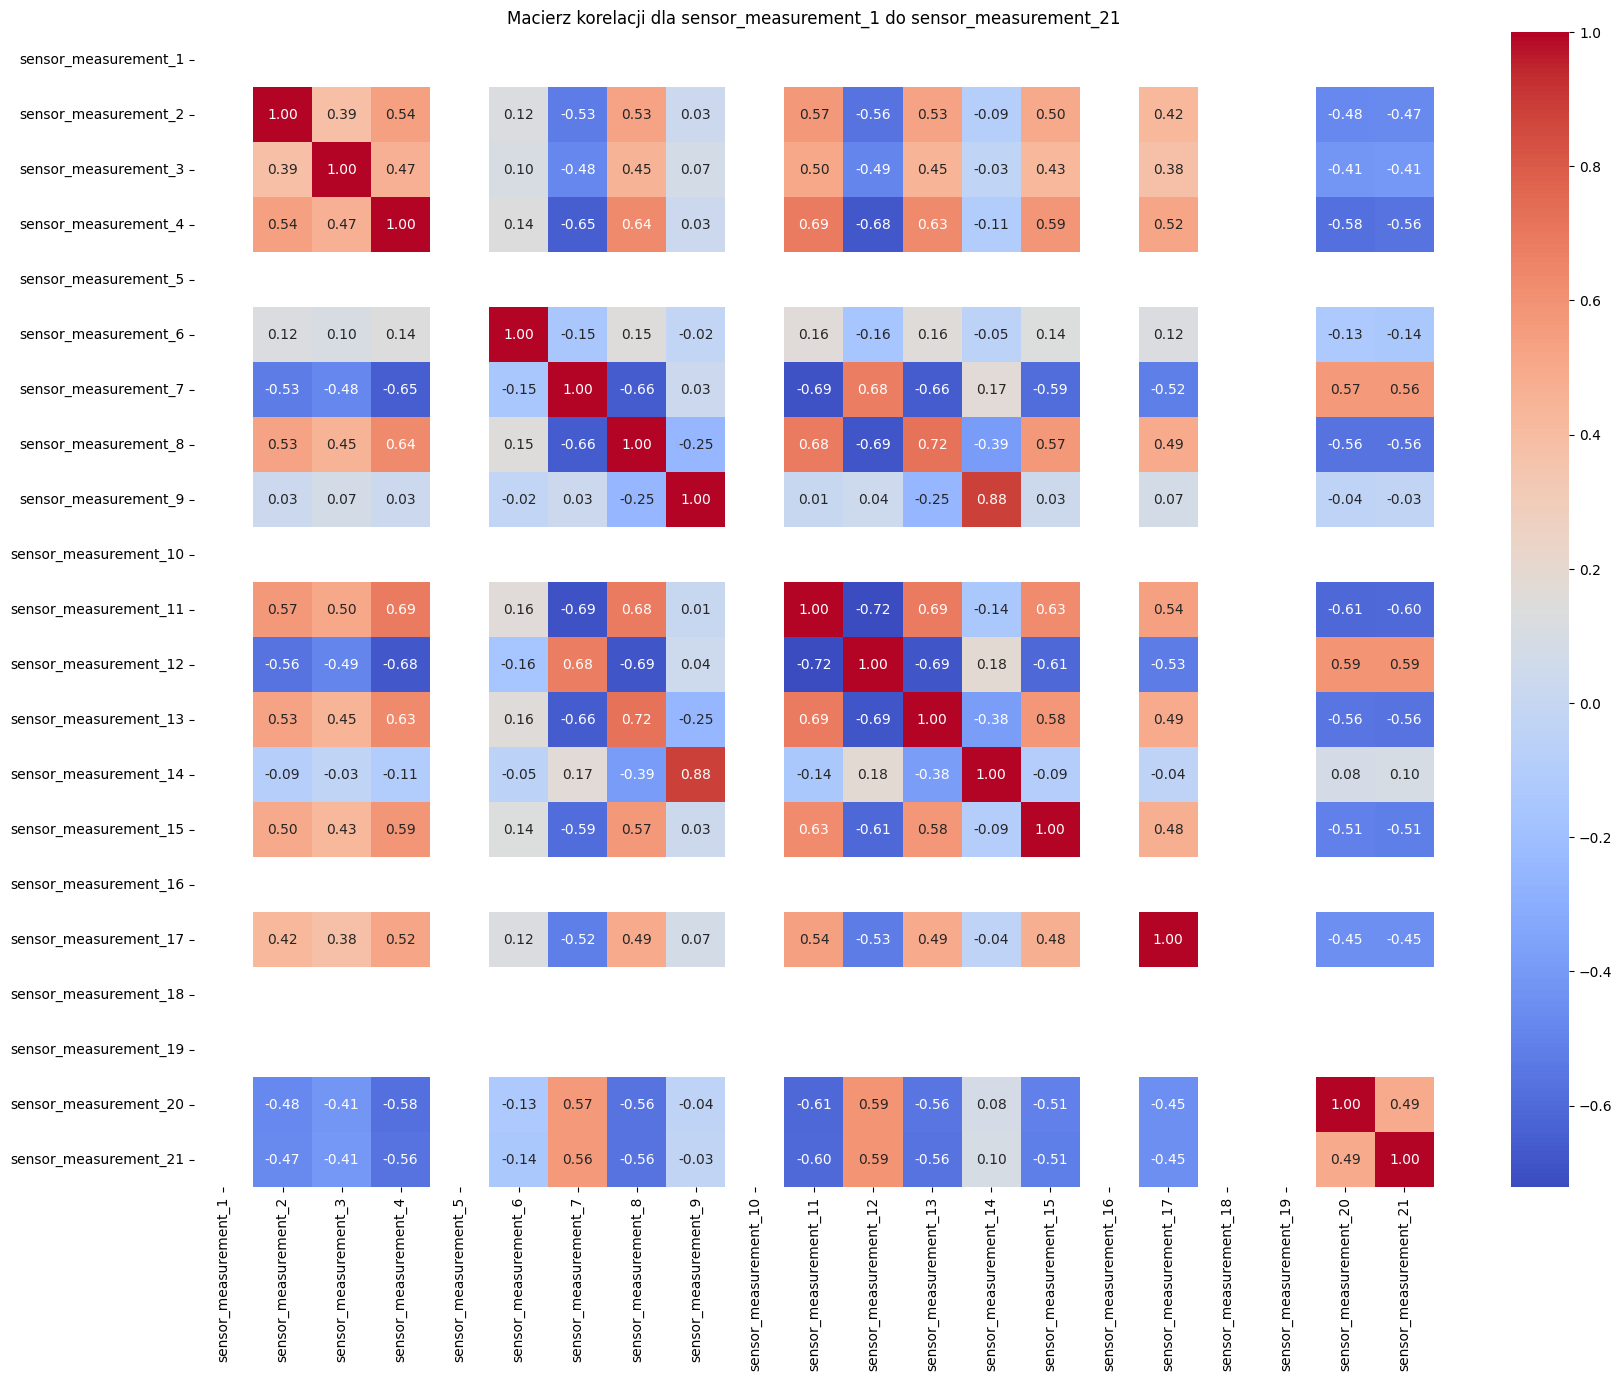

In [ ]:
# Wczytanie danych
data = pd.read_csv('/content/drive/Othercomputers/Mój laptop/Documents/Data science/V semestr/Uczenie maszynowe/Zadanie domowe 5 (regularyzacja)/dataset_train.csv', sep=',')

# Wybór kolumn z sensor_measurement_1 do sensor_measurement_21
sensor_columns = [f'sensor_measurement_{i}' for i in range(1, 22)]
sensor_data = data[sensor_columns]

# Obliczenie macierzy korelacji
correlation_matrix = sensor_data.corr()

# Wizualizacja macierzy korelacji
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji dla sensor_measurement_1 do sensor_measurement_21')
plt.show()

Sprawdziłem, czy istnieją parametry skorelowane w 100% ze sobą. Po zweryfikowaniu, że nie ma takich par przechodzę do dalszej analizy.

In [ ]:
# Definicja zmiennej objaśnianej (y) oraz objaśniających (X) dla zbioru treningowego
X_train = dataset_train.drop(columns=['sensor_measurement_4', 'unit_number'])  # Usuwamy również 'unit_number', ponieważ jest identyfikatorem
y_train = dataset_train['sensor_measurement_4']

X_test = dataset_test.drop(columns=['sensor_measurement_4', 'unit_number'])  # Usuwamy również 'unit_number', ponieważ jest identyfikatorem
y_test = dataset_test['sensor_measurement_4']

# Budowa modelu regresji liniowej dla zbioru treningowego
lm = LinearRegression()
lm.fit(X_train, y_train)

# Obliczenie współczynnika determinacji (R2) dla zbioru treningowego
r2_train = r2_score(y_train, lm.predict(X_train))

# Test na zbiorze testowym bez retreningu
r2_test = r2_score(y_test, lm.predict(X_test))

# Wyniki
print("Współczynnik determinacji (R2) - treningowy:", r2_train)
print("Współczynnik determinacji (R2) - testowy:", r2_test)

Współczynnik determinacji (R2) - treningowy: 0.7816067537118878
Współczynnik determinacji (R2) - testowy: 0.60668614448333


In [ ]:
# Dodanie stałej do zmiennych objaśniających (potrzebne dla statsmodels)
X_train_with_const = sm.add_constant(X_train)

# Budowa modelu OLS (Ordinary Least Squares)
model_ols = sm.OLS(y_train, X_train_with_const).fit()

# Wyświetlenie podsumowania statystycznego
print(model_ols.summary())

# Interpretacja wyników:
# - Istotność statystyczna parametrów sprawdzana jest za pomocą p-wartości (kolumna "P>|t|")
# - Parametry o p-wartościach poniżej 0.05 są uznawane za statystycznie istotne

                             OLS Regression Results                             
Dep. Variable:     sensor_measurement_4   R-squared:                       0.782
Model:                              OLS   Adj. R-squared:                  0.781
Method:                   Least Squares   F-statistic:                     4611.
Date:                  Wed, 29 Jan 2025   Prob (F-statistic):               0.00
Time:                          13:30:17   Log-Likelihood:                -58911.
No. Observations:                 20631   AIC:                         1.179e+05
Df Residuals:                     20614   BIC:                         1.180e+05
Df Model:                            16                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
op_setting

Analizując istotność statystyczną parametrów, usuwam te, które są statystycznie nieistotne (p-wartość > 0.05):

*   `op_setting_1` (p = 0.168)
*   `op_setting_2` (p = 0.366)
*   `sensor_measurement_6` (p = 0.396)
*   `sensor_measurement_14` (p = 0.863)

In [ ]:
# Przygotowanie danych treningowych z usunięciem zmiennych statystycznie nieistotnych
X_train = dataset_train.drop(columns=['sensor_measurement_4', 'unit_number', 'op_setting_1', 'op_setting_2', 'sensor_measurement_6', 'sensor_measurement_14'])
y_train = dataset_train['sensor_measurement_4']

In [ ]:
X_test = dataset_test.drop(columns=['sensor_measurement_4', 'unit_number', 'op_setting_1', 'op_setting_2', 'sensor_measurement_6', 'sensor_measurement_14'])
y_test = dataset_test['sensor_measurement_4']

## 3. Zbudowanie modeli regresji z regularyzacją

### Ridge Regression (L2)

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

### Lasso Regression (L1)

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

In [ ]:
for alpha in [0.001, 0.01, 0.1, 1]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    r2_train = r2_score(y_train, lasso.predict(X_train))
    r2_test = r2_score(y_test, lasso.predict(X_test))
    print(f"Alpha: {alpha}, R2 Train: {r2_train:.4f}, R2 Test: {r2_test:.4f}")

Alpha: 0.001, R2 Train: 0.7815, R2 Test: 0.6068
Alpha: 0.01, R2 Train: 0.7786, R2 Test: 0.6019
Alpha: 0.1, R2 Train: 0.7609, R2 Test: 0.5722
Alpha: 1, R2 Train: 0.7048, R2 Test: 0.4828


Zwiększenie wartości alpha (lambda) nie poprawia sprawności modelu. Wybieram `alpha = 0.01` , który będzie kompromisem bez dużej utraty jakości

### Elastic Net (L1 + L2)

In [ ]:
from sklearn.linear_model import ElasticNet

elastic_net_model = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic_net_model.fit(X_train, y_train)

y_train_pred_elastic = elastic_net_model.predict(X_train)
y_test_pred_elastic = elastic_net_model.predict(X_test)

r2_train_elastic = r2_score(y_train, y_train_pred_elastic)
r2_test_elastic = r2_score(y_test, y_test_pred_elastic)

### Prezentacja współczynników modeli

In [ ]:
print("Współczynniki modelu liniowego:", lm.coef_)
print("Współczynniki modelu Ridge:", ridge_model.coef_)
print("Współczynniki modelu Lasso:", lasso_model.coef_)
print("Współczynniki modelu Elastic Net:", elastic_net_model.coef_)

Współczynniki modelu liniowego: [ 1.84811938e+01  9.03549423e+01 -4.67159644e-12  9.41690104e-01
  6.78892250e-02 -1.62869718e-12  1.81693819e+01 -1.03230661e+00
  1.35263650e+01  3.99793392e-02 -2.22044605e-13  5.49353570e+00
 -1.80880558e+00  1.27469163e+01  1.10485062e-03  1.78185977e+01
  9.23034387e-25  2.77843881e-01 -3.82419979e+00 -4.79804505e+00]
Współczynniki modelu Ridge: [ 0.00000000e+00  9.61171880e-01  6.88621920e-02  4.96352575e-23
 -1.05517364e+00  1.31777120e+01  4.04143435e-02  0.00000000e+00
  5.57647437e+00 -1.83762728e+00  1.24698403e+01  1.62303938e+01
  3.87775449e-25  2.84077712e-01 -3.87545789e+00 -4.84296633e+00]
Współczynniki modelu Lasso: [ 0.          1.17951922  0.08811199  0.         -1.35518657  9.2644042
  0.03518082  0.          6.36735482 -2.27862566  8.57456997  0.
  0.          0.37213014 -4.02712028 -3.87260777]
Współczynniki modelu Elastic Net: [ 0.          1.47929555  0.10770098  0.         -1.70065704  3.30631471
  0.02519386  0.          5.778

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'Elastic Net'],
    'R2 Train': [r2_train, r2_train_ridge, r2_train_lasso, r2_train_elastic],
    'R2 Test': [r2_test, r2_test_ridge, r2_test_lasso, r2_test_elastic]
})

print(results)

         Model  R2 Train   R2 Test
0       Linear  0.781607  0.606686
1        Ridge  0.781550  0.606815
2        Lasso  0.778579  0.601859
3  Elastic Net  0.774120  0.594980


### Porównanie modeli regresji

* Regresja liniowa
Przy regresji liniowej widoczna jest dość duża różnica we współczynniku determinacji między modelem treningowym, a testowym. Może to świadczyć o przeuczeniu.

* Ridge (L2 regularization)
Ridge (L2 regularization) ma bardzo podobne dopasowanie do regresji liniowej, co sugeruje, że penalizacja wag nie wpłynęła znacząco na wydajność.

* Lasso (L1 regularization)
Lasso (L1 regularization) zredukowało niektóre współczynniki do zera. Nieco gorszy wynik na zbiorze testowym wskazuje, że model być może zbyt mocno ograniczył zmienne.

* Elastic Net (L1 + L2 regularization)
Elastic Net (L1 + L2 regularization) prezentuje się gorzej niż pozostałe modele, co może być spowodowane nadmiernym wpływem obu penalizacji.